#### Importar librerias

In [1]:

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick
import matplotlib.dates as mdatesx
import matplotlib.transforms as transforms
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from scipy.interpolate import make_interp_spline
from matplotlib.ticker import FuncFormatter
import calendar

#### Seleccionar Fecha

In [2]:
ANIO = 2026
MES = 5

df = pd.DataFrame()
df["anio"] = ANIO
df["mes"] = MES

#### Drive - Colab

In [ ]:
######### Para usar con colab ###########
### Comentar si se usa fuera de colab ###
"""
import os
from google.colab import drive

drive.mount('/content/drive')
ruta_drive = r"/content/drive/MyDrive/_DPAEE/Automatización de Informes"
os.listdir(ruta_drive)

carpeta = f"{ANIO}-{MES}"
ruta_completa = os.path.join(ruta_drive, carpeta)

# Crear carpeta (no tira error si ya existe)
os.makedirs(ruta_completa, exist_ok=True)

#### Entorno local

In [ ]:
############## Para usar en entorno local #################
###### Comentar si se usa fuera de un entorno local #######

ruta = r"C:/Users\janis\Desktop\DPAEE/Automatización de Informes\Fiscal"
ruta = r"C:\Users\janis\Desktop\DPAEE\Automatización de Informes\Fiscal\Gráficos Fiscal\Nación"

carpeta = f"{ANIO}-{MES}"
ruta_completa = os.path.join(ruta, carpeta)

# Crear carpeta (no tira error si ya existe)
os.makedirs(ruta_completa, exist_ok=True)

#### BBDD - Fiscal

In [ ]:
fiscal_db = pd.read_excel("Fiscal_BBDD_Agus.xlsx")
fiscal_db.columns = fiscal_db.columns.str.strip()
pd.set_option('display.float_format', '{:.2f}'.format)
#fiscal_db.tail()

In [ ]:
fiscal_db = fiscal_db.rename(columns={'Otros': 'Resto'})
fiscal_db['Fecha'] = pd.to_datetime(fiscal_db['Fecha'], dayfirst=True)  # dayfirst=True si tus fechas son dd/mm/yyyy
fiscal_db.insert(1, 'Año', fiscal_db['Fecha'].dt.year)
fiscal_db.set_index('Fecha', inplace=True)

fiscal_db = fiscal_db.fillna(0)

fiscal_db ['Aportes y Cont SS'] =   (
                                    fiscal_db['Aportes Personales'] +
                                    fiscal_db['Contribuciones Patronales'] +
                                    fiscal_db['Otros ingresos Seguridad Social  (4)'] -
                                    fiscal_db['Otros SIPA (-)']
                                    )

In [ ]:
cols_restar = [
    "Ganancias",
    "IVA",
    "Bienes Personales",
    "Internos Coparticipados",
    "Derechos de Exportación",
    "Derechos de Importación y Tasa Estadistica",
    "Impuesto P.A.I.S.",
    "Regularización de Activos",
    "Créditos y Débitos en Cta. Cte.",
    "Aportes y Cont SS",
    "Combustibles Total (2)",
            ]

# Crear nueva variable
fiscal_db["resto tributario"] = fiscal_db["Total recursos tributarios"] - fiscal_db[cols_restar].sum(axis=1)
fiscal_db['resto tributario'] = fiscal_db['resto tributario'] + fiscal_db['Regularización de Activos']


In [ ]:
# Crear Deflactor sobre el último dato de IPC

ultimo_valor = fiscal_db['IPC Dic16=100'].iloc[-1]

fiscal_db['deflactor'] = fiscal_db['IPC Dic16=100'] / ultimo_valor

In [ ]:
# Cálculo de las variables Deflactadas + Incorporación a la base

fiscal_db['IVA_defl'] = fiscal_db['IVA']/fiscal_db['deflactor']
fiscal_db['Bienes Personales_defl'] = fiscal_db['Bienes Personales']/fiscal_db['deflactor']
fiscal_db['Ganancias_defl'] = fiscal_db['Ganancias']/fiscal_db['deflactor']
fiscal_db['Resto_defl'] = fiscal_db['Resto']/fiscal_db['deflactor']
fiscal_db['Total recursos tributarios_defl'] = fiscal_db['Total recursos tributarios']/fiscal_db['deflactor']
fiscal_db['Internos Coparticipados_defl'] = fiscal_db['Internos Coparticipados']/fiscal_db['deflactor']
fiscal_db['Combustibles Total (2)_defl'] = fiscal_db['Combustibles Total (2)']/fiscal_db['deflactor']
fiscal_db['Créditos y Débitos en Cta. Cte.'] = fiscal_db['Créditos y Débitos en Cta. Cte.']/fiscal_db['deflactor']
fiscal_db['Derechos de Exportación_defl'] = fiscal_db['Derechos de Exportación']/fiscal_db['deflactor']
fiscal_db['Derechos de Importación y Tasa Estadistica'] = fiscal_db['Derechos de Importación y Tasa Estadistica']/fiscal_db['deflactor']
fiscal_db['Impuesto P.A.I.S._defl'] = fiscal_db['Impuesto P.A.I.S.']/fiscal_db['deflactor']
fiscal_db['resto tributario_defl'] = fiscal_db['resto tributario']/fiscal_db['deflactor']
fiscal_db['Aportes y Cont SS_defl'] = fiscal_db['Aportes y Cont SS']/fiscal_db['deflactor']




In [ ]:
# Cálculo YoY / Variacones Interanuales

cols = ['Total recursos tributarios_defl',
        'IVA_defl',
        'Ganancias_defl',
        'Bienes Personales_defl',
        'Resto_defl',
        'Internos Coparticipados_defl',
        'Combustibles Total (2)_defl',
        'Créditos y Débitos en Cta. Cte.',
        'Derechos de Exportación_defl',
        'Derechos de Importación y Tasa Estadistica',
        'Impuesto P.A.I.S._defl',
        'resto tributario_defl',
        'Aportes y Cont SS_defl'
        ]

for col in cols:
    fiscal_db[col + '_yoy'] = fiscal_db[col].pct_change(periods=12) * 100

In [ ]:
# Acumulado al último mes de cada año

for col in cols:
    fiscal_db[col + '_acum'] = fiscal_db.groupby('Año')[col].cumsum()

# YoY Acum %

cols_acum = ['Total recursos tributarios_defl_acum', 'IVA_defl_acum', 'Ganancias_defl_acum', 'Bienes Personales_defl_acum', 'Resto_defl_acum']

for col in cols_acum:
    fiscal_db[col + '_yoy%acum'] = fiscal_db[col].pct_change(periods=12) * 100

fiscal_db['IVA + Ganancias_defl_yoy%acum'] = (fiscal_db['IVA_defl_acum'] + fiscal_db['Ganancias_defl_acum']).pct_change(periods=12) * 100

#fiscal_db['resto tributario_defl_acum'].tail(20)

## Gráficos

#### Gráfico de barras montos últimos 12 meses:
* IVA
* Ganancias
* Bienes Personales
* Resto

In [ ]:
# Creación del DataFrame

barras = ['IVA', 'Ganancias', 'Bienes Personales', 'Resto']
ultimo_12_meses = fiscal_db.tail(12)
df_grafico = ultimo_12_meses[barras].copy()
df_grafico.index = df_grafico.index.to_period('M')

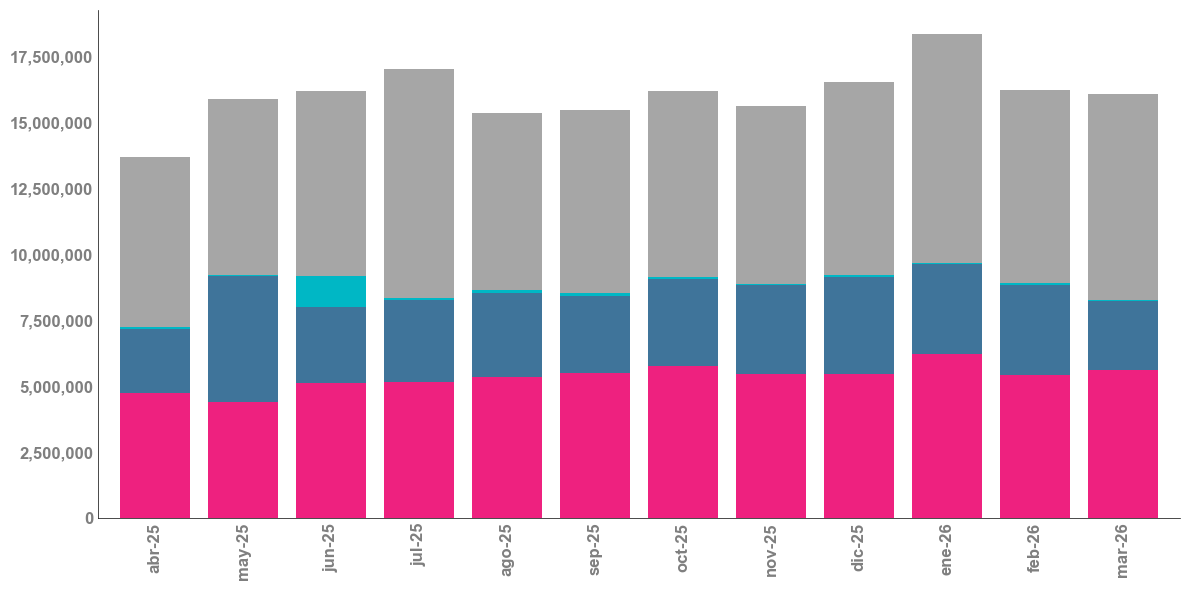

In [ ]:
# Crear figura y eje
fig, ax = plt.subplots(figsize=(12,6))

# Graficar barras apiladas con colores personalizados
df_grafico.plot(kind='bar', stacked=True, ax=ax,
                color=['#EE217F', '#3F749A', '#00B7C5', '#A6A6A6'],
                width=0.8)

# Rotar etiquetas eje x
plt.xticks(rotation=90)

# Lista de meses en español
meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

# Crear etiquetas para cada fecha de tu índice
fechas_esp = [f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}" for d in df_grafico.index]

# Asignar etiquetas al eje x
ax.set_xticklabels(fechas_esp, rotation=90)

# Quitar etiqueta del eje x
ax.set_xlabel('')

# Quitar recuadro (spines) superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Quitar ticks del eje x e y
ax.tick_params(axis='x', which='both', length=0)
ax.tick_params(axis='y', which='both', length=0)

# Hacer líneas de los ejes más finas
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Cambiar fuente a Arial negrita tamaño 12 para ticks y títulos y color gris
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(12)
    label.set_color('#7F7F7F')

# Cambiar fuente para etiqueta eje y
ax.yaxis.label.set_fontname('Arial')
ax.yaxis.label.set_fontweight('bold')
ax.yaxis.label.set_fontsize(12)
ax.yaxis.label.set_color('#7F7F7F')

# Formatear eje y con separadores de miles y aplicar fuente Arial negrita 12 y color gris
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontname('Arial')
    tick.label1.set_fontsize(12)
    tick.label1.set_fontweight('bold')
    tick.label1.set_color('#7F7F7F')

plt.legend().remove()
plt.tight_layout()

plt.savefig(os.path.join(ruta_completa, '1. Barras montos últimos 12 meses.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()


#### Gráfico de líneas YoY últimos 12 meses:
* IVA-YoY
* Ganancias-Yoy
* Bienes Personales
* Resto


C:\Users\janis\AppData\Local\Temp\ipykernel_9796\1875200985.py:238: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


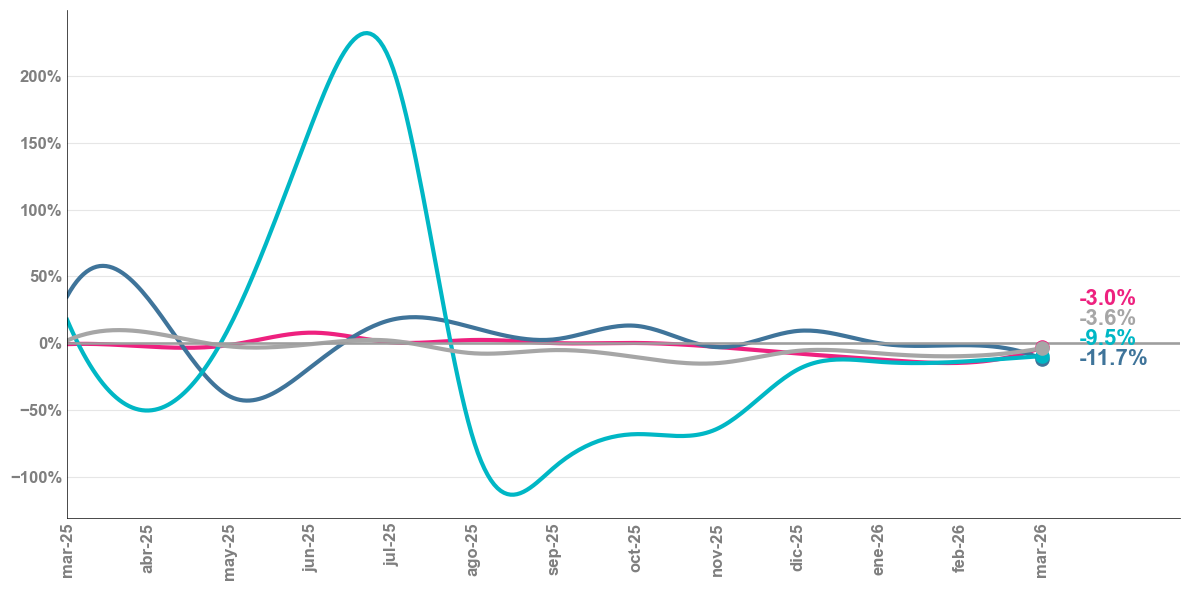

In [ ]:
# -----------------------------
# Datos
# -----------------------------

variables = [
    'IVA_defl',
    'Ganancias_defl',
    'Bienes Personales_defl',
    'Resto_defl'
]

df_vi = fiscal_db[variables].pct_change(12) * 100
df_vi = df_vi.tail(13)

# -----------------------------
# Índice
# -----------------------------

x = list(range(len(df_vi)))

# -----------------------------
# Figura
# -----------------------------

fig, ax = plt.subplots(figsize=(12,6))

colors = [
    '#EE217F',
    '#3F749A',
    '#00B7C5',
    '#A6A6A6'
]

# -----------------------------
# Calcular posiciones finales
# -----------------------------

min_sep = 15

curve_data = {}

last_points = []

for i, col in enumerate(variables):

    y = df_vi[col].values.astype(float)

    x_new = np.linspace(min(x), max(x), 300)

    spline = make_interp_spline(
        x,
        y,
        k=3
    )

    y_smooth = spline(x_new)

    curve_data[col] = {
        'x_new': x_new,
        'y_smooth': y_smooth,
        'y_real': float(y[-1])
    }

    last_points.append({
        'col': col,
        'y_curve': float(y_smooth[-1]),
        'y_real': float(y[-1])
    })

# ordenar según altura visual
last_points = sorted(
    last_points,
    key=lambda d: d['y_curve']
)

# primera posición
last_points[0]['y_label'] = last_points[0]['y_curve']

# aplicar separación mínima
for i in range(1, len(last_points)):

    prev_y = last_points[i-1]['y_label']

    current_y = last_points[i]['y_curve']

    last_points[i]['y_label'] = max(
        current_y,
        prev_y + min_sep
    )

# diccionario final
label_dict = {
    d['col']: d['y_label']
    for d in last_points
}

# -----------------------------
# Dibujar líneas
# -----------------------------

for i, col in enumerate(variables):

    x_new = curve_data[col]['x_new']

    y_smooth = curve_data[col]['y_smooth']

    last_y = curve_data[col]['y_real']

    # línea
    ax.plot(
        x_new,
        y_smooth,
        color=colors[i],
        linewidth=3
    )

    # punto final
    ax.scatter(
        x_new[-1],
        y_smooth[-1],
        color=colors[i],
        s=90,
        zorder=5
    )

    # etiqueta final
    ax.text(
        x[-1] + 0.45,
        label_dict[col],
        f"{last_y:.1f}%",
        color=colors[i],
        fontsize=16,
        fontweight='bold',
        fontname='Arial',
        va='center'
    )

# -----------------------------
# Espacio para etiquetas
# -----------------------------

ax.set_xlim(min(x), max(x) + 1.7)

# -----------------------------
# Eje X
# -----------------------------

meses_esp = [
    'ene', 'feb', 'mar', 'abr', 'may', 'jun',
    'jul', 'ago', 'sep', 'oct', 'nov', 'dic'
]

fechas_esp = [
    f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in df_vi.index
]

ax.set_xticks(x)

ax.set_xticklabels(
    fechas_esp,
    rotation=90
)

ax.tick_params(
    axis='x',
    which='both',
    length=0
)

# -----------------------------
# Eje Y
# -----------------------------

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)

ax.tick_params(
    axis='y',
    which='both',
    length=0
)

# -----------------------------
# Bordes
# -----------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# -----------------------------
# Fuente
# -----------------------------

for label in (
    ax.get_xticklabels() +
    ax.get_yticklabels()
):

    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(12)
    label.set_color('#7F7F7F')

# -----------------------------
# Líneas base
# -----------------------------

ax.axhline(
    y=0,
    color='#9E9E9E',
    linewidth=1,
    zorder=0
)

ax.axhline(
    0,
    color='#9E9E9E',
    linewidth=1.8
)

# -----------------------------
# Grid
# -----------------------------

ax.grid(
    axis='y',
    color='#E6E6E6',
    linewidth=0.8
)

ax.set_xlabel('')

plt.legend().remove()

plt.tight_layout()

plt.savefig(os.path.join(ruta_completa, '2. Barras YoY montos últimos 12 meses.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico de barras comparativas último mes y año anterior
* IVA
* Ganancias
* Bienes Personales
* Resto

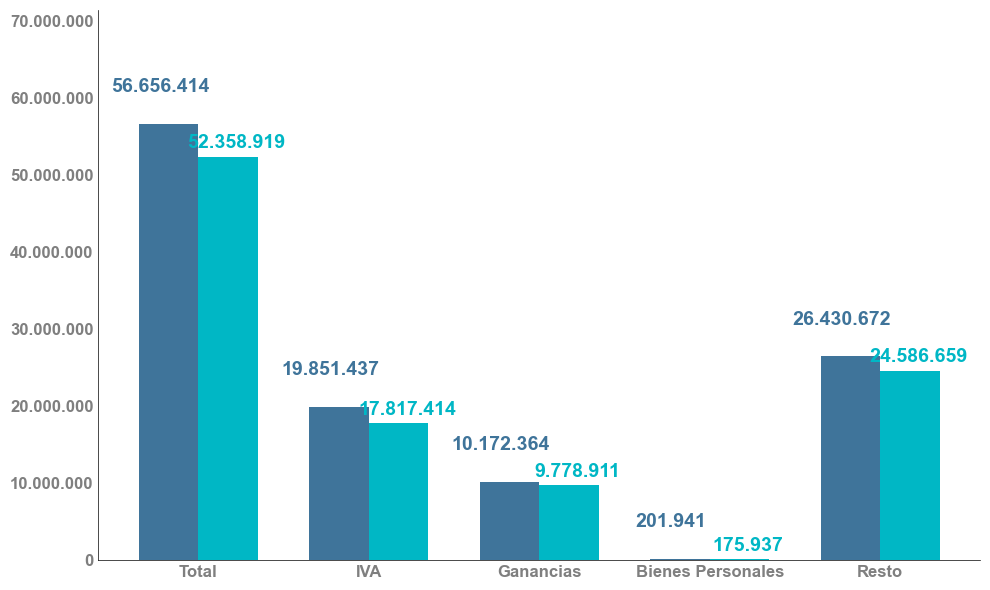

In [ ]:
# Seleccionar último mes y año anterior
ultimo_mes = fiscal_db.iloc[-1]
año_anterior = fiscal_db.iloc[-13]

etiquetas_1 = ['Total recursos tributarios_defl_acum',
              'IVA_defl_acum',
              'Ganancias_defl_acum',
              'Bienes Personales_defl_acum',
              'Resto_defl_acum']

val_ultimo_1 = ultimo_mes[etiquetas_1].values
val_anterior_1 = año_anterior[etiquetas_1].values

x = np.arange(len(etiquetas_1))
ancho = 0.35


fig, ax = plt.subplots(figsize=(10, 6))

barras1 = ax.bar(x - ancho/2, val_anterior_1, width=ancho, color='#3F749A')
barras2 = ax.bar(x + ancho/2, val_ultimo_1, width=ancho, color='#00B7C5')

# Formato del eje Y (números completos)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', '.')))

# Extender el rango del eje Y hacia arriba un 20%
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.2)

ax.set_xticks(x)
ax.set_xticklabels(['Total','IVA', 'Ganancias', 'Bienes Personales', 'Resto'])

# Quitar recuadro (spines) superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Quitar ticks del eje x e y
ax.tick_params(axis='x', which='both', length=0)
ax.tick_params(axis='y', which='both', length=0)

# Hacer líneas de los ejes más finas
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Estilo de ticks
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(12)
    label.set_color('#7F7F7F')

import matplotlib.transforms as transforms

# --- Separación fija en píxeles ---
offset_pixels_barra1 = 20   # separa 20 píxeles de la parte superior de la barra 1
offset_pixels_barra2 = 3   # separa 20 píxeles de la parte superior de la barra 2

# Etiquetas para barras1
for b in barras1:
    height = b.get_height()

    # Conversión del offset en pixeles al sistema del eje
    trans = transforms.ScaledTranslation(0, offset_pixels_barra1/72, fig.dpi_scale_trans)
    ax.text(
        b.get_x() + b.get_width()/2 - 0.05,
        height,
        f'{height:,.0f}'.replace(',', '.'),
        transform=ax.transData + trans,   # Aplicar desplazamiento REAL
        ha='center', va='bottom',
        fontsize=14, fontname='Arial', color='#3F749A', fontweight='bold'
    )

# Etiquetas para barras2
for b in barras2:
    height = b.get_height()

    trans = transforms.ScaledTranslation(0, offset_pixels_barra2/72, fig.dpi_scale_trans)
    ax.text(
        b.get_x() + b.get_width()/2 + 0.05,
        height,
        f'{height:,.0f}'.replace(',', '.'),
        transform=ax.transData + trans,
        ha='center', va='bottom',
        fontsize=14, fontname='Arial', color='#00B7C5', fontweight='bold'
    )

plt.tight_layout()

plt.savefig(os.path.join(ruta_completa, '3. Barras comparativas último mes y año anterior.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()


#### Gráfico de barras horizontales con eje centrado YoY:
* IVA
* Ganancias
* Bienes Personales
* Resto

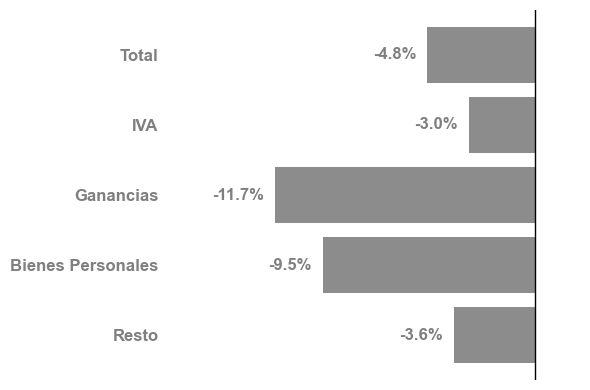

In [ ]:

etiquetas_2 = ["Resto" , "Bienes Personales" , "Ganancias" , "IVA" , "Total"]

variables_2 = ['Resto_defl' , 'Bienes Personales_defl' , 'Ganancias_defl' , 'IVA_defl' , 'Total recursos tributarios_defl']

df_vi = fiscal_db[variables_2].pct_change(12) * 100

# Convertir variación en vector
variacion = df_vi.tail(1).values.flatten()

# Crear figura
fig, ax = plt.subplots(figsize=(6, 4))

# Posiciones
y = np.arange(len(etiquetas_2))

# Colores iguales al ejemplo
ax.barh(y, variacion, color="#8C8C8C")

# Línea vertical en cero
ax.axvline(0, color='black', linewidth=1)

# Etiquetas a la izquierda
ax.set_yticks(y)
ax.set_yticklabels(etiquetas_2, fontname="Arial", fontsize=12, color="#7F7F7F", fontweight='bold')
ax.tick_params(axis='y', length=0)

# Ocultar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Grid vertical
ax.xaxis.grid(False)

# Ocultar el eje x
ax.get_xaxis().set_visible(False)

# Texto de valores
for i, v in enumerate(variacion):
    ax.text(
        v + (0.5 if v >= 0 else -0.5),
        i,
        f"{v:.1f}%",
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=12,
        color="#7F7F7F",
        fontweight="bold"
    )

# Quitar etiquetas de ejes
ax.set_xlabel("")
ax.set_ylabel("")

# Espacio para etiquetas
ax.set_xlim(min(variacion) - 5, max(variacion) + 5)

plt.tight_layout()

plt.savefig(os.path.join(ruta_completa, '4. Barras horizontales con eje centrado YoY.png'),
            dpi=300,
            bbox_inches='tight')
plt.show()


#### Gráfico de barras apiladas montos acumulados del último año y del anterior:
* Impuestos a la actividad
* Impuestos patrimoniales
* Impuestos al comercio exterior
* Aportes y contribuciones a la seguridad social
* Resto tributario

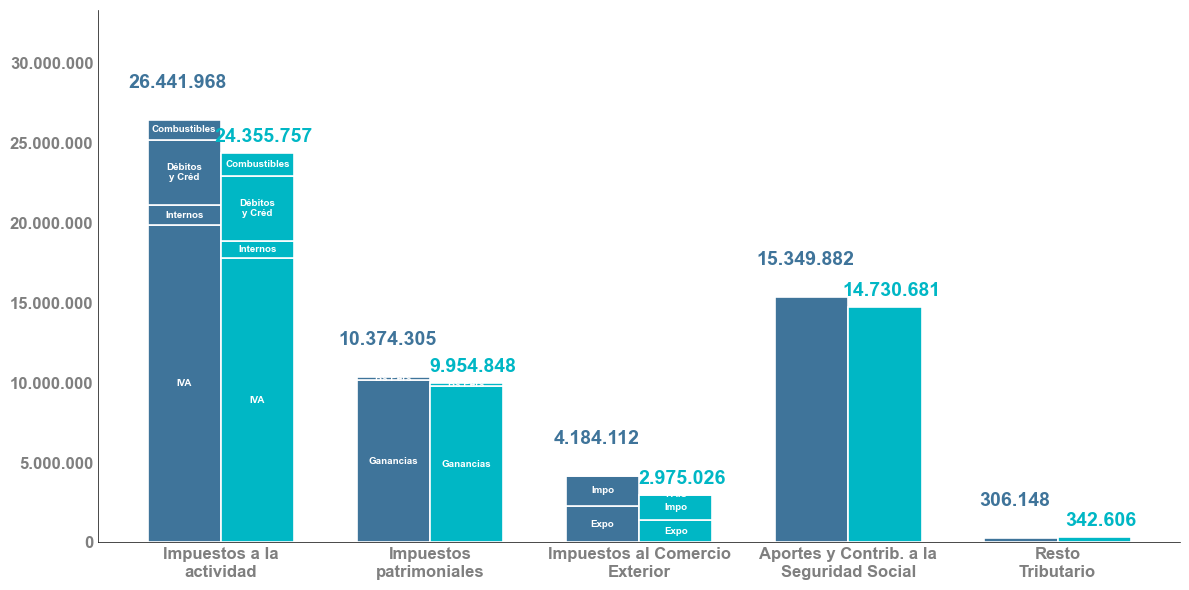

In [ ]:

# ========================
# 1) Definir los grupos
# ========================

grupos = [
    "Impuestos a la actividad",
    "Impuestos patrimoniales",
    "Impuestos al Comercio Exterior",
    "Aportes y Contrib. a la Seguridad Social",
    "Resto Tributario"
]

labels_grupos = [
    "Impuestos a la\nactividad",
    "Impuestos\npatrimoniales",
    "Impuestos al Comercio\nExterior",
    "Aportes y Contrib. a la\nSeguridad Social",
    "Resto\nTributario"
]

labels_componentes = {
    "IVA_defl_acum": "IVA",
    "Internos Coparticipados_defl_acum": "Internos",
    "Créditos y Débitos en Cta. Cte._acum": "Débitos\ny Créd",
    "Combustibles Total (2)_defl_acum": "Combustibles",
    "Ganancias_defl_acum": "Ganancias",
    "Bienes Personales_defl_acum": "Bs Pers",
    "Derechos de Exportación_defl_acum": "Expo",
    "Derechos de Importación y Tasa Estadistica_acum": "Impo",
    "Impuesto P.A.I.S._defl_acum": "PAIS"
}

# ========================
# 2) Componentes por grupo
# ========================

estructura = {
    "Impuestos a la actividad": [
        "IVA_defl_acum",
        "Internos Coparticipados_defl_acum",
        "Créditos y Débitos en Cta. Cte._acum",
        "Combustibles Total (2)_defl_acum"
    ],
    "Impuestos patrimoniales": [
        "Ganancias_defl_acum",
        "Bienes Personales_defl_acum"
    ],
    "Impuestos al Comercio Exterior": [
        "Derechos de Exportación_defl_acum",
        "Derechos de Importación y Tasa Estadistica_acum",
        "Impuesto P.A.I.S._defl_acum"
    ],
    "Aportes y Contrib. a la Seguridad Social": [
        "Aportes y Cont SS_defl_acum"
    ],
    "Resto Tributario": [
        "resto tributario_defl_acum"
    ]
}

# ========================
# 3) Datos
# ========================

fila_2024 = fiscal_db.iloc[-13].fillna(0)
fila_2025 = fiscal_db.iloc[-1].fillna(0)

# ========================
# 4) Colores
# ========================

color_2024 = "#3F749A"
color_2025 = "#00B7C5"
edgecolor = "white"
linewidth = 1.2

# ========================
# 5) Plot
# ========================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(grupos))
width = 0.35

for i, grupo in enumerate(grupos):

    columnas = estructura[grupo]
    es_apilado = len(columnas) > 1

    bottom_2024 = 0
    bottom_2025 = 0

    for col in columnas:

        val_2024 = fila_2024[col]
        val_2025 = fila_2025[col]

        # Barras
        ax.bar(
            x[i] - width/2, val_2024, width,
            bottom=bottom_2024,
            color=color_2024,
            edgecolor=edgecolor,
            linewidth=linewidth
        )

        ax.bar(
            x[i] + width/2, val_2025, width,
            bottom=bottom_2025,
            color=color_2025,
            edgecolor=edgecolor,
            linewidth=linewidth
        )

        # Etiquetas internas (solo si es apilado)
        if es_apilado and val_2024 > 0:
            ax.text(
                x[i] - width/2,
                bottom_2024 + val_2024 / 2,
                labels_componentes.get(col, ""),
                ha="center", va="center",
                fontsize=7,
                fontname="Arial",
                fontweight="bold",
                color="white"
            )

        if es_apilado and val_2025 > 0:
            ax.text(
                x[i] + width/2,
                bottom_2025 + val_2025 / 2,
                labels_componentes.get(col, ""),
                ha="center", va="center",
                fontsize=7,
                fontname="Arial",
                fontweight="bold",
                color="white"
            )

        bottom_2024 += val_2024
        bottom_2025 += val_2025

# ========================
# 6) Estética
# ========================

ax.set_xticks(x)
ax.set_xticklabels(labels_grupos)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
)

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Arial")
    label.set_fontweight("bold")
    label.set_fontsize(12)
    label.set_color("#7F7F7F")

# ========================
# 7) Totales arriba de cada barra
# ========================

offset_2024 = 20
offset_2025 = 5

for i, grupo in enumerate(grupos):

    columnas = estructura[grupo]

    total_2024 = sum(fila_2024[col] for col in columnas)
    total_2025 = sum(fila_2025[col] for col in columnas)

    trans_2024 = transforms.ScaledTranslation(0, offset_2024/72, fig.dpi_scale_trans)
    trans_2025 = transforms.ScaledTranslation(0, offset_2025/72, fig.dpi_scale_trans)

    ax.text(
        x[i] - width/2 - 0.03,
        total_2024,
        f"{total_2024:,.0f}".replace(",", "."),
        transform=ax.transData + trans_2024,
        ha="center", va="bottom",
        fontsize=14, fontname="Arial",
        fontweight="bold", color=color_2024
    )

    ax.text(
        x[i] + width/2 + 0.03,
        total_2025,
        f"{total_2025:,.0f}".replace(",", "."),
        transform=ax.transData + trans_2025,
        ha="center", va="bottom",
        fontsize=14, fontname="Arial",
        fontweight="bold", color=color_2025
    )

plt.tight_layout()

plt.savefig(os.path.join(ruta_completa, '5. Barras apiladas último mes y año anterior.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()
